# Hierarchical Clustering


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier

from scipy.cluster.hierarchy import linkage, dendrogram

In [ ]:
df = pd.read_csv('/content/CleanedData.csv')

# Drop target columns (adjust if needed)
X = df.drop(columns=['Status', 'TimeInMonths'])


*   Silhouette → higher is better
*   Davies-Bouldin → lower is better
*   Calinski-Harabasz → higher is better


In [ ]:
categorical_cols = [
    'Topology', 'Morphology_Group', 'DiagnosisMethod',
    'I10', 'Laterality', 'Grade', 'OtherTreatment'
]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(sparse_output=False, drop='first'), categorical_cols)
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
)

X_processed = preprocessor.fit_transform(X)

In [ ]:
range_n_clusters = range(3, 11)

results = []

for n_clusters in range_n_clusters:
    model = AgglomerativeClustering(n_clusters=n_clusters)
    labels = model.fit_predict(X_processed)

    sil = silhouette_score(X_processed, labels)
    db = davies_bouldin_score(X_processed, labels)
    ch = calinski_harabasz_score(X_processed, labels)

    results.append((n_clusters, sil, db, ch))

results_df = pd.DataFrame(results, columns=['k', 'silhouette', 'davies_bouldin', 'calinski_harabasz'])
print("\nCluster Evaluation Metrics:\n", results_df)


Cluster Evaluation Metrics:
     k  silhouette  davies_bouldin  calinski_harabasz
0   3    0.123454        2.728786         154.921062
1   4    0.091165        2.505606         142.962085
2   5    0.111486        2.571187         132.239165
3   6    0.127200        2.607657         122.975570
4   7    0.109958        2.444614         115.380514
5   8    0.115738        2.454599         108.468485
6   9    0.104287        2.477419         102.147198
7  10    0.092992        2.489523          95.900999


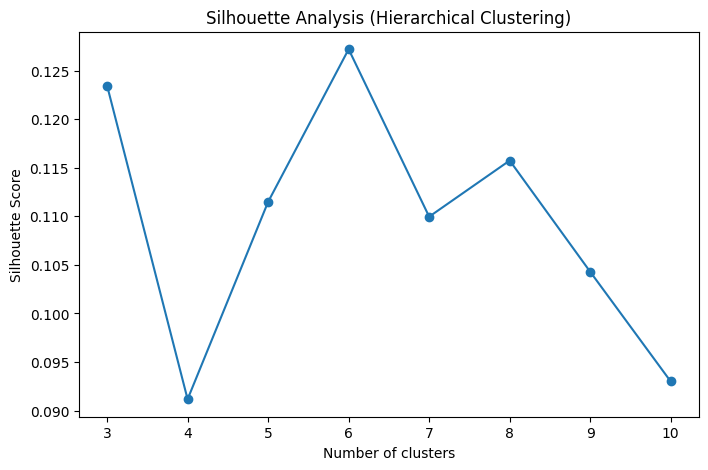

In [ ]:
# Plot silhouette scores
plt.figure(figsize=(8,5))
plt.plot(results_df['k'], results_df['silhouette'], marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis (Hierarchical Clustering)')
plt.show()

In [ ]:
# Choose best k (based on silhouette)
optimal_k = results_df.loc[results_df['silhouette'].idxmax(), 'k']
print(f"\nOptimal number of clusters: {optimal_k}")



Optimal number of clusters: 6


In [ ]:
hc_model = AgglomerativeClustering(n_clusters=optimal_k)
df['Cluster'] = hc_model.fit_predict(X_processed)


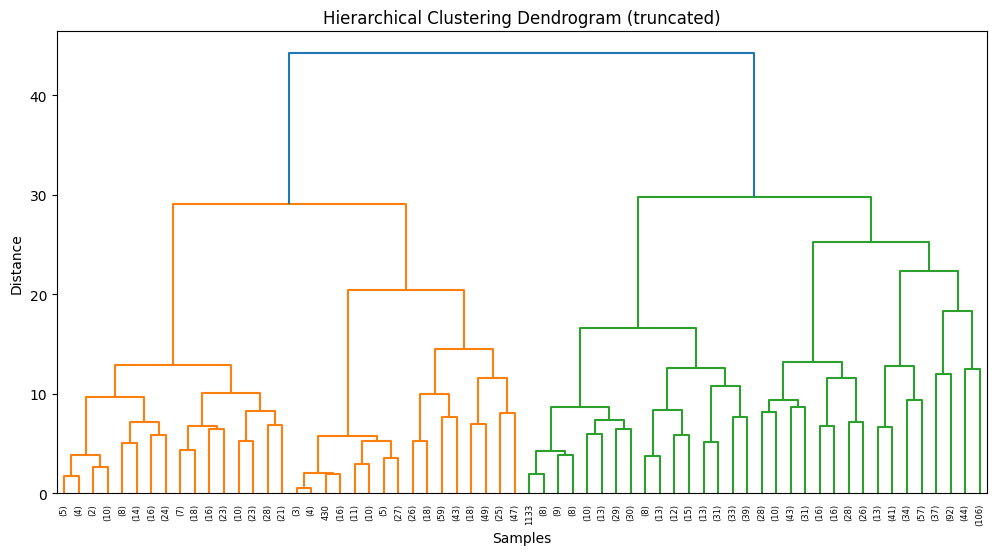

In [ ]:
linked = linkage(X_processed, method='ward')

plt.figure(figsize=(12,6))
dendrogram(linked, truncate_mode='level', p=5)
plt.title('Hierarchical Clustering Dendrogram (truncated)')
plt.xlabel('Samples')
plt.ylabel('Distance')
plt.show()


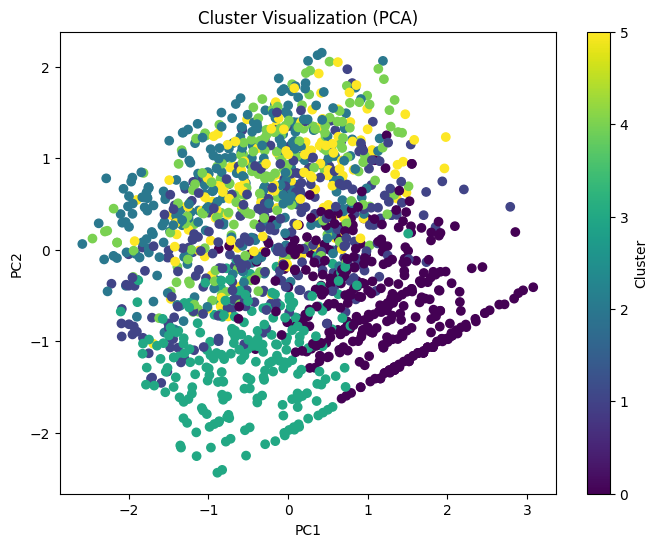

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_processed)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['Cluster'], cmap='viridis')
plt.title("Cluster Visualization (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label='Cluster')
plt.show()

In [ ]:
feature_names = preprocessor.get_feature_names_out()
X_df = pd.DataFrame(X_processed, columns=feature_names)
X_df['Cluster'] = df['Cluster']

In [ ]:
cluster_summary = X_df.groupby('Cluster').mean()
overall_mean = X_df.drop(columns='Cluster').mean()

print("\nTop 3 Determinants per Cluster (Mean Difference):")

for cluster in cluster_summary.index:
    diff = cluster_summary.loc[cluster] - overall_mean
    top_features = diff.abs().sort_values(ascending=False).head(3)

    print(f"\nCluster {cluster}:")
    for feature in top_features.index:
        print(f"  {feature} (diff = {diff[feature]:.4f})")


Top 3 Determinants per Cluster (Mean Difference):

Cluster 0:
  Age (diff = 0.7321)
  I10_C719 (diff = 0.5916)
  Topology_719 (diff = 0.5844)

Cluster 1:
  I10_C719 (diff = -0.3686)
  Topology_719 (diff = -0.3348)
  I10_C711 (diff = -0.1704)

Cluster 2:
  I10_C711 (diff = 0.7968)
  Topology_711 (diff = 0.7944)
  Topology_719 (diff = -0.4101)

Cluster 3:
  Age (diff = -0.9639)
  Topology_719 (diff = 0.5855)
  I10_C719 (diff = 0.5809)

Cluster 4:
  I10_C713 (diff = 0.8391)
  Topology_713 (diff = 0.8370)
  Topology_719 (diff = -0.4101)

Cluster 5:
  I10_C712 (diff = 0.9017)
  Topology_712 (diff = 0.9010)
  Topology_719 (diff = -0.4101)


# K Means


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
from sklearn.decomposition import PCA

In [ ]:
# Check scikit-learn version in Colab
import sklearn
print("scikit-learn version:", sklearn.__version__)

scikit-learn version: 1.6.1


In [ ]:
df = pd.read_csv('/content/CleanedData.csv')

# Drop target column only
X = df.drop(columns=['Status', 'TimeInMonths'])

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

categorical_cols = [
    'Topology', 'Morphology_Group', 'DiagnosisMethod',
    'I10', 'Laterality', 'Grade', 'OtherTreatment'
]

binary_cols = [
    'Chemotherapy', 'FamilyHistory', 'Radiotherapy',
    'Surgery', 'Sex'
]

numeric_cols = ['Age']

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
    ('bin', 'passthrough', binary_cols),
    ('num', StandardScaler(), numeric_cols)
])

In [ ]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('pca', PCA(n_components=0.90, random_state=42)),
    ('kmeans', KMeans(n_clusters=5, random_state=42, n_init=50))
])

In [ ]:
pipeline.fit(X)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Topology',
                                                   'Morphology_Group',
                                                   'DiagnosisMethod', 'I10',
                                                   'Laterality', 'Grade',
                                                   'OtherTreatment'])],
                                   verbose_feature_names_out=False)),
                ('pca', PCA(n_components=0.9, random_state=42)),
                ('kmeans',
                 KMeans(max_iter=500, n_clusters=5, n_init=50,
                        random_state=42))])

In [ ]:
K_range = range(3, 11)

sse = []
sil_scores = []
db_scores = []
ch_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=50, max_iter=500)
    labels = kmeans.fit_predict(X_pca)

    sse.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_pca, labels))
    db_scores.append(davies_bouldin_score(X_pca, labels))
    ch_scores.append(calinski_harabasz_score(X_pca, labels))

# Create results table
results_df = pd.DataFrame({
    'k': list(K_range),
    'SSE': sse,
    'Silhouette': sil_scores,
    'Davies_Bouldin': db_scores,
    'Calinski_Harabasz': ch_scores
})

print("\nCluster Evaluation Metrics:\n", results_df)


Cluster Evaluation Metrics:
     k          SSE  Silhouette  Davies_Bouldin  Calinski_Harabasz
0   3  5670.501685    0.132360        2.208489         232.052720
1   4  5324.428526    0.140689        2.181209         196.732803
2   5  5056.738545    0.152920        2.196236         174.842367
3   6  4809.523527    0.134358        2.142754         162.168664
4   7  4599.777351    0.129636        2.191421         152.439919
5   8  4423.117441    0.139597        2.183467         144.216909
6   9  4277.633680    0.140480        2.222210         136.668118
7  10  4179.723984    0.133063        2.183818         128.083346


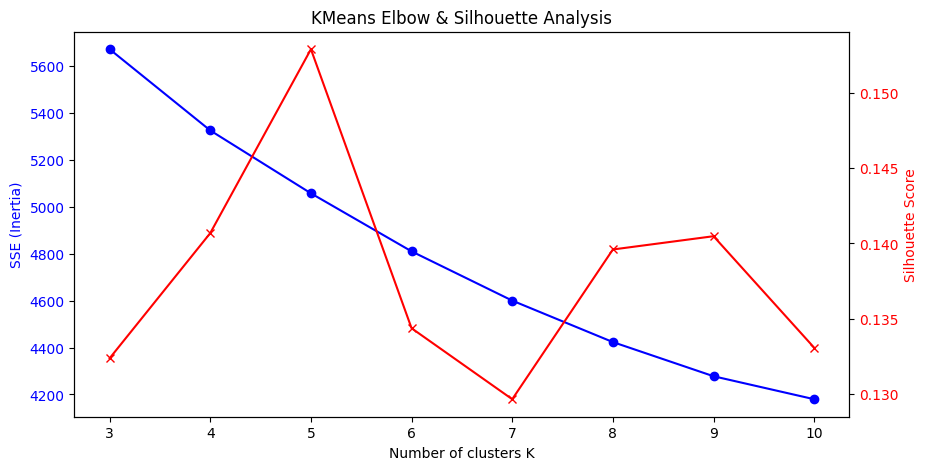

In [ ]:
fig, ax1 = plt.subplots(figsize=(10,5))

# SSE
ax1.set_xlabel('Number of clusters K')
ax1.set_ylabel('SSE (Inertia)', color='blue')
ax1.plot(K_range, sse, marker='o', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Silhouette
ax2 = ax1.twinx()
ax2.set_ylabel('Silhouette Score', color='red')
ax2.plot(K_range, sil_scores, marker='x', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title("KMeans Elbow & Silhouette Analysis")
plt.show()

In [ ]:
optimal_k = results_df.loc[results_df['Silhouette'].idxmax(), 'k']
print(f"\nOptimal K based on silhouette: {optimal_k}")


Optimal K based on silhouette: 5


In [ ]:
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=50, max_iter=500)
labels_final = kmeans_final.fit_predict(X_pca)

df['Cluster'] = labels_final

print("Final Silhouette Score:", silhouette_score(X_pca, labels_final))
print("Cluster counts:\n", df['Cluster'].value_counts())


Final Silhouette Score: 0.15291973176071794
Cluster counts:
 Cluster
0    413
4    349
3    283
2    262
1    178
Name: count, dtype: int64


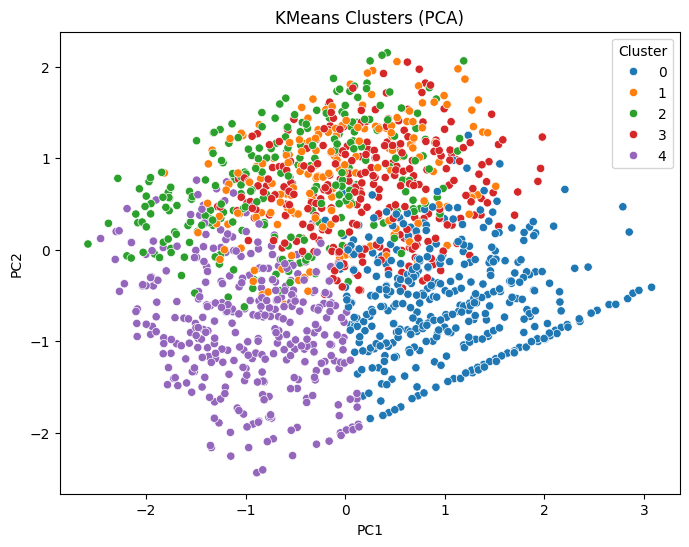

In [ ]:
pca_vis = PCA(n_components=2, random_state=42)
X_pca_vis = pca_vis.fit_transform(X_processed)

df['PC1'] = X_pca_vis[:,0]
df['PC2'] = X_pca_vis[:,1]

plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='PC1', y='PC2', hue='Cluster', palette='tab10')
plt.title("KMeans Clusters (PCA)")
plt.show()

In [ ]:
feature_names = preprocessor.get_feature_names_out()
X_df = pd.DataFrame(X_processed, columns=feature_names)
X_df['Cluster'] = df['Cluster']

The avarage here refres to the average of each feature across the entire dataset, ignoring clusters.
*   Positive value → feature is higher than average in this cluster
*   Negative value → feature is lower than average




In [ ]:
cluster_summary = X_df.groupby('Cluster').mean()
overall_mean = X_df.drop(columns='Cluster').mean()

print("\nTop 3 Determinants per Cluster:")

for cluster in cluster_summary.index:
    diff = cluster_summary.loc[cluster] - overall_mean
    top_features = diff.abs().sort_values(ascending=False).head(3)

    print(f"\nCluster {cluster}:")
    for feature in top_features.index:
        print(f"  {feature} (diff = {diff[feature]:.4f})")


Top 3 Determinants per Cluster:

Cluster 0:
  Age (diff = 0.6827)
  Topology_719 (diff = 0.5754)
  I10_C719 (diff = 0.5712)

Cluster 1:
  Topology_713 (diff = 0.8673)
  I10_C713 (diff = 0.8581)
  Topology_719 (diff = -0.4101)

Cluster 2:
  Topology_711 (diff = 0.8128)
  I10_C711 (diff = 0.8036)
  Topology_719 (diff = -0.4101)

Cluster 3:
  Age (diff = 0.4769)
  Topology_719 (diff = -0.4030)
  I10_C719 (diff = -0.3973)

Cluster 4:
  Age (diff = -1.2140)
  Topology_719 (diff = 0.1630)
  Morphology_Group_Glioblastoma (diff = -0.1587)


In [ ]:
import pickle

with open('kmeans_pipeline.pkl', 'wb') as f:
    pickle.dump(pipeline, f)

print("Model saved as kmeans_pipeline.pkl")

Model saved as kmeans_pipeline.pkl
